# MuTrans Analaysis of IPS Reprogramming Dataset

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(3, 3), facecolor='white')
import matplotlib.pyplot as plt
import pyMuTrans as pm

datadir = "../Data/"
adata = sc.read_csv(datadir+'data_ipsc.csv') # load the pre-processed data
genes = pd.read_csv(datadir+'ipsc_genes.csv',header=None)
time = pd.read_csv(datadir+'ipsc_time.csv',header= None)
adata.var_names = genes.iloc[:,0]
adata.obs['time'] = time.values

/Users/cliffzhou/opt/anaconda3/lib/python3.7/site-packages/pyemma/__init__.py:92: UserWarning: You are not using the latest release of PyEMMA. Latest is 2.5.7, you have 2.5.6.
  .format(latest=latest, current=current), category=UserWarning)


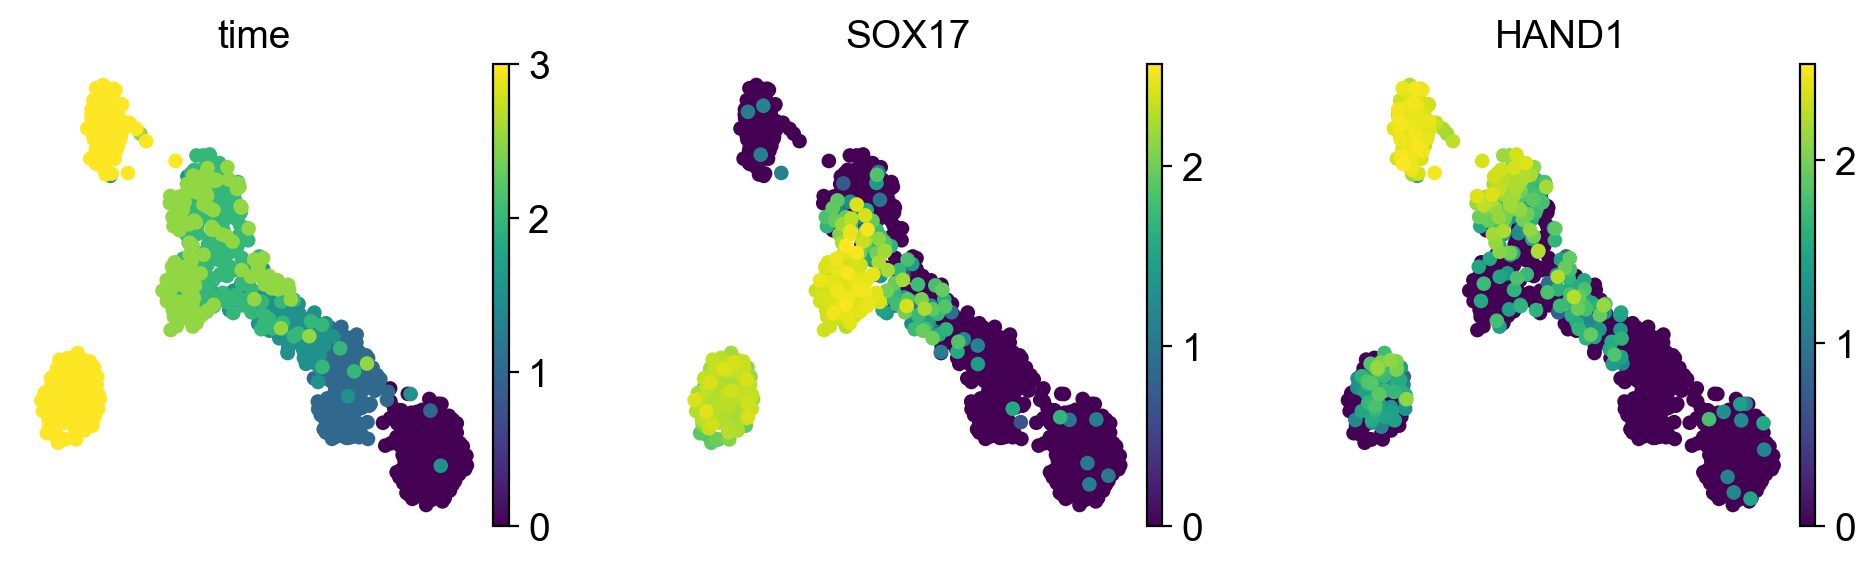

In [2]:
sc.pp.neighbors(adata,metric = 'cosine',n_neighbors=60, use_rep='X')
sc.tl.umap(adata)
sc.pl.umap(adata, color = ['time','SOX17','HAND1'])

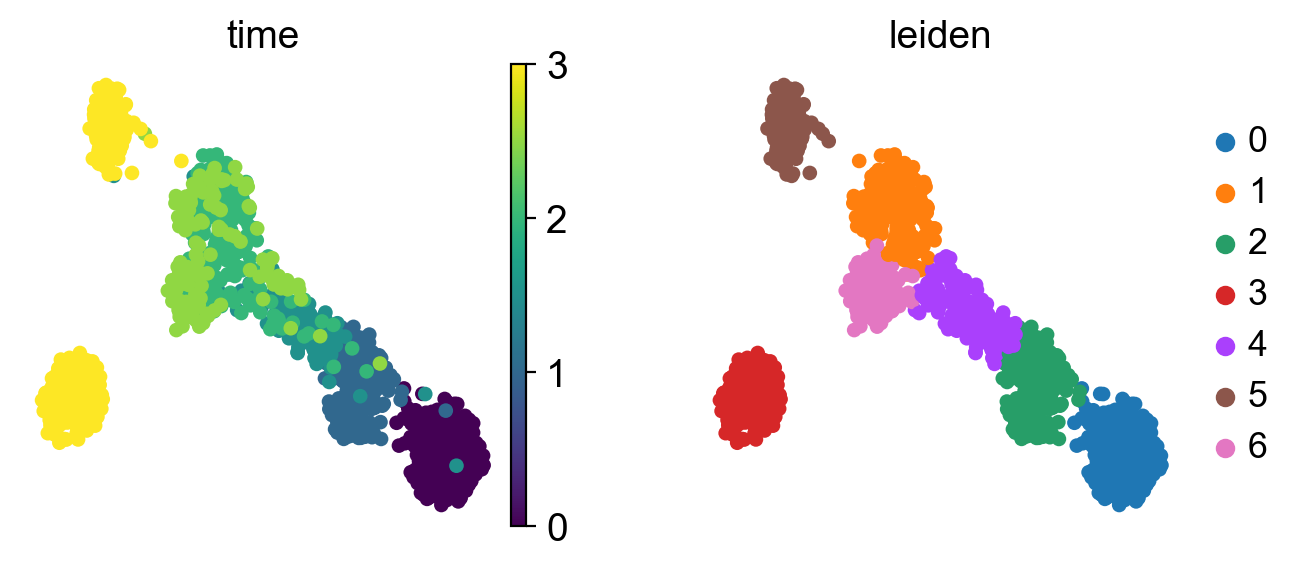

In [3]:
sc.tl.leiden(adata,resolution = 1.0)
sc.pl.umap(adata, color=['time','leiden'])

## Estimate Cluster Number with EPI (Eigen-Peak Index)

In [ ]:
fig = plt.figure(figsize=(6, 3))
par = {"choice_distance":"euclid"}
out = pm.plot_cluster_num(adata, par, k_plot= 10) #look for the peaks

## MuTrans Analysis Based on the AnnData Object

In [ ]:
par = {"choice_distance":"cosine","perplex":200.0,"K_cluster":9.0,"trials":10,"reduction_coord":'umap',"weight_scale":False,"write_anndata":True} 
adata = pm.dynamical_analysis(adata,par)

In [ ]:
import seaborn as sns
color_palette = sns.color_palette('Set3', 9)
temp = color_palette [6]
color_palette[6] = color_palette[7] # for reproduce the order in Matlab notebook
color_palette[7] = temp
sc.pl.umap(adata, color=['attractor','entropy','SOX17','HAND1'],vmax = 'p95',palette = color_palette)

In [ ]:
adata.obs['attractor'].value_counts()

## Examine the Entropy of Transition Cells

In [ ]:
adata.obs['time'] = adata.obs['time'].astype(str)
sc.pl.violin(adata, keys = ['entropy'], groupby='time')

In [ ]:
ax = sns.boxplot(x="time", y="entropy", data=adata.obs)

In [ ]:
sc.pl.violin(adata, keys = ['entropy'], groupby='attractor',palette = color_palette)

## Transition Path Analysis

In [ ]:
fig = plt.figure(figsize=(10, 6))
pm.infer_lineage(adata,si=0,sf=4,method = "MPPT",flux_fraction = 0.3,size_point =40,alpha_point = 0.5,size_text = 15,color_palette=color_palette)

In [ ]:
fig = plt.figure(figsize=(10, 6))
pm.infer_lineage(adata,si=0,sf=4,method = "MPFT",flux_fraction = 0.3,size_point =40,alpha_point = 0.5,size_text = 15,color_palette=color_palette)

## Visualization of Gene Analysis Results

In [ ]:
sc.pl.umap(adata, color=['MSX2','TBX2','entropy'])

In [ ]:
adata_sub = adata[adata.obs['attractor'].isin(['6', '4']),:]

In [ ]:
adata_sub

In [ ]:
sc.pl.umap(adata_sub, color=['TBX2','ISL1','TBX20','entropy'],vmin = 'p80',vmax = 'p99')

In [ ]:
sc.pl.embedding(adata_sub, color=['TBX2','ISL1','TBX20','entropy'],vmin = 'p80',vmax = 'p99',basis = 'trans_coord')

In [ ]:
sc.pl.violin(adata_sub, keys = ['TBX2','TBX20','MYL4'], groupby='attractor',palette = [color_palette[4],color_palette[6]])

In [ ]:
sc.pl.umap(adata_sub, color=['TBX20','entropy'],vmin = 'p50')

In [ ]:
sc.pl.umap(adata_sub, color=['MYL4','entropy'])

In [ ]:
sc.pl.embedding(adata_sub, color=['MYL4','entropy'],vmin = 'p20',vmax = 'p99',basis = 'trans_coord')

With the bifurcating state:

In [ ]:
adata_ps = adata[adata.obs['attractor'].isin(['2']),:]

In [ ]:
sc.pl.umap(adata_ps, color=['GATA6','MESP2','EMILIN2','entropy'],vmin = 'p30',vmax = 'p99')

In [ ]:
sc.pl.embedding(adata_ps, color=['GATA6','MESP2','EMILIN2','entropy'],vmin = 'p30',vmax = 'p99',basis = 'trans_coord')

## Changing the number of clusters K

In [ ]:
par['K_cluster'] = 7.0
adata = pm.dynamical_analysis(adata,par)

In [ ]:
sc.pl.umap(adata, color=['attractor','entropy','SOX17','HAND1'],palette = color_palette)

In [ ]:
sc.pl.violin(adata, keys = ['entropy'], groupby='attractor')

In [ ]:
adata.obs['time'] = adata.obs['time'].astype(str)
sc.pl.violin(adata, keys = ['entropy'], groupby='time')

In [ ]:
fig = plt.figure(figsize=(8, 8))
pm.infer_lineage(adata,si=0,sf=3,method = "MPPT",flux_fraction = 0.6,size_point =40,alpha_point = 0.5, color_palette =color_palette )

In [ ]:
par['K_cluster'] = 5.0
adata = pm.dynamical_analysis(adata,par)
sc.pl.umap(adata, color=['attractor','entropy','SOX17','HAND1'])

In [ ]:
adata.obs['time'] = adata.obs['time'].astype(str)
sc.pl.violin(adata, keys = ['entropy'], groupby='time')

In [ ]:
fig = plt.figure(figsize=(8, 8))
pm.infer_lineage(adata,si=0,sf=2,method = "MPPT",flux_fraction = 0.5,size_point =40,alpha_point = 0.5,color_palette =color_palette)

## Population Balance Analysis

In [ ]:
#output to PBA
import numpy as np
np.save('X',adata.X)
R = np.zeros(1081)
np.save('R',R)

In [ ]:
S = np.zeros((1081,2))
M_id = adata.obs['attractor'].to_numpy()=='2'
En_id = adata.obs['attractor'].to_numpy()=='4'
S[random.choice(np.argwhere(M_id == True)),0] = 1
S[random.choice(np.argwhere(En_id == True)),1] = 1
np.save('S',S)

In [ ]:
# load the computation results of PBA
B = np.load('B_ipsc.npy')
V = np.load('V_ipsc.npy')
T = np.load('T_ipsc.npy')

In [ ]:
adata.obs['m_fate_prob'] = B[:,0]
adata.obs['en_fate_prob']= B[:,1]
np.random.seed(0)
init_cell = random.choice(np.argwhere(adata.obs['attractor'].to_numpy()=='0'))
adata.obs['mfpt'] = T[int(init_cell),:]

In [ ]:
sc.pl.umap(adata, color=['m_fate_prob','en_fate_prob','mfpt'],vmin = ['p10','p10','p30'],vmax = 'p99')

In [ ]:
sc.pl.violin(adata, keys = ['mfpt'], groupby='time')

In [ ]:
from scipy.stats import kendalltau
kendalltau(adata.obs['time'],adata.obs['mfpt'])

In [ ]:
from scipy.stats import spearmanr
spearmanr(adata.obs['time'].to_numpy().astype('float'),adata.obs['mfpt'])

In [ ]:
from scipy.stats import pearsonr
pearsonr(adata.obs['time'].to_numpy().astype('float'),adata.obs['mfpt'])